# 03. GNN Risk Allocation

**Goal**: Implement Step 3 of the pipeline: a GNN-based portfolio allocator.

This notebook will:
1.  **Load Graph Snapshots**: Train/Val/Test datasets created in step 2.
2.  **Attach Realized Returns**: Compute 1-day forward realized returns for each graph date to serve as the training signal.
3.  **Define `RiskGNN` Model**: A GCN that outputs portfolio weights ($w_t$) for the stocks in the graph.
4.  **Train with Sharpe + CVaR Loss**: Optimize the model to maximize Sharpe ratio while penalizing tail risk (CVaR).

**Key Design Choice**:
The loss function is designed to accept a `return_vector`. Currently, we fill this with **historical realized returns**. 
Later, this interface allows us to easily swap in (or mix) **LSTM forecasted returns** without changing the model architecture.

## 1. Imports & Configuration

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv
from torch_geometric.utils import softmax
from torch_geometric.data import Data

warnings.filterwarnings("ignore")

# Setup Paths
DATA_DIR = Path("../../data")
GRAPH_DIR = DATA_DIR / "Graphs"

# Configuration
CONFIG = {
    "batch_size": 64,
    "hidden_dim": 64,
    "num_layers": 2,
    "dropout": 0.3,
    "lr": 1e-5,
    "weight_decay": 1e-4,
    "num_epochs": 100,
    "risk_aversion": 1.0,  # For Mean-Variance utility
    "portfolio_temp": 2.0, # Temperature for softmax (logits -> weights)
    "return_horizon": 20,   # 20-day ahead realized return target
    
    # CVaR Parameters
    "cvar_alpha": 0.95,    # Confidence level for CVaR
    "lambda_cvar": 1,    # Weight for CVaR penalty
    "use_cvar_sharpe": False  # if True, use mu / (-CVaR) instead of mu/sigma
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 2. Load Data

### 2.1 Load Graph Snapshots
We load the pre-built graph datasets.

In [2]:
train_graphs = torch.load(GRAPH_DIR / "EGX30_Graphs_train.pt", weights_only=False)
val_graphs   = torch.load(GRAPH_DIR / "EGX30_Graphs_val.pt",   weights_only=False)
test_graphs  = torch.load(GRAPH_DIR / "EGX30_Graphs_test.pt",  weights_only=False)

print(f"Loaded Graphs: Train={len(train_graphs)}, Val={len(val_graphs)}, Test={len(test_graphs)}")

# Inspect one sample
g_sample = train_graphs[0]
print("\nSample Graph:")
print(g_sample)
print(f"Date: {g_sample.date}")
print(f"Tickers: {g_sample.tickers[:5]} ...")

Loaded Graphs: Train=1928, Val=115, Test=174

Sample Graph:
Data(x=[30, 9], edge_index=[2, 240], date='2017-01-08', tickers=[30], num_nodes=30, degrees=[30])
Date: 2017-01-08
Tickers: ['ABUK', 'ADIB', 'AMOC', 'ARCC', 'BTFH'] ...


### 2.2 Compute Realized Returns

We need the **forward-looking** realized return for each graph. 
If the graph represents the state at close of day $t$, we want to optimize the portfolio for the return over period $(t, t+k]$.

We will:
1. Load the aligned price panel.
2. Compute log returns shifted backwards by `return_horizon` (so index $t$ contains return $t \to t+k$).
3. Attach these returns to the graph objects.

In [3]:
# 1. Load Prices
prices_path = list(DATA_DIR.glob("EGX30_OHLCV*.csv"))[0]
prices_df = pd.read_csv(prices_path, index_col=0, parse_dates=True)

# Ensure column order matches the alphanumeric sorting used in graph construction
# (The graphs were built using sorted columns, so we must match that)
prices_df = prices_df.reindex(sorted(prices_df.columns), axis=1)

# 2. Compute Forward Log Returns
log_prices = np.log(prices_df)

# Return at 't' = ln(P_{t+h}) - ln(P_t)
# We use shift(-h) to align future return with current date 't'
horizon = CONFIG["return_horizon"]
log_returns_forward = log_prices.shift(-horizon) - log_prices

print(f"Computed forward returns (horizon={horizon}). Shape: {log_returns_forward.shape}")
log_returns_forward.index = log_returns_forward.index.normalize()
log_returns_forward.iloc[-5:, :5]

Computed forward returns (horizon=20). Shape: (2297, 26)


,ABUK,ADIB,AMOC,ARCC,BTFH
datetime,,,,,
2026-03-05,NaN,NaN,NaN,NaN,NaN
2026-03-08,NaN,NaN,NaN,NaN,NaN
2026-03-09,NaN,NaN,NaN,NaN,NaN
2026-03-10,NaN,NaN,NaN,NaN,NaN
2026-03-11,NaN,NaN,NaN,NaN,NaN


In [4]:
# === Dynamically align graph tickers to available CSV tickers ===

# Universe of tickers actually present in the CSV/returns
available_tickers = set(log_returns_forward.columns)
print(f"Number of available tickers in returns: {len(available_tickers)}")
print("Sample available tickers:", list(log_returns_forward.columns[:10]))

def filter_graph_to_available_tickers(g, available):
    """
    Filter a PyG Data graph to keep only nodes whose tickers are in `available`.
    Creates a CLEAN NEW graph object to avoid mutation issues.
    """
    # 1) Identify nodes to keep
    keep_mask = torch.tensor([t in available for t in g.tickers], dtype=torch.bool)
    
    if keep_mask.sum() == 0:
        return None
    
    # 2) Create mapping: old_idx -> new_idx
    old_to_new = {}
    new_idx = 0
    for old_idx in range(len(g.tickers)):
        if keep_mask[old_idx]:
            old_to_new[old_idx] = new_idx
            new_idx += 1
    
    num_kept = new_idx
    
    # 3) Filter node features and tickers
    new_x = g.x[keep_mask].clone()  # CRITICAL: clone to avoid shared memory
    new_tickers = [g.tickers[i] for i in range(len(g.tickers)) if keep_mask[i]]
    
    # 4) Rebuild edges
    new_edges = []
    if g.edge_index is not None and g.edge_index.numel() > 0:
        src, dst = g.edge_index[0].tolist(), g.edge_index[1].tolist()
        
        for u, v in zip(src, dst):
            # Both endpoints must be kept
            if u in old_to_new and v in old_to_new:
                new_u = old_to_new[u]
                new_v = old_to_new[v]
                
                # Sanity check
                if new_u >= num_kept or new_v >= num_kept:
                    print(f"WARNING: Impossible edge ({u},{v}) -> ({new_u},{new_v}) with {num_kept} nodes")
                    continue
                
                new_edges.append([new_u, new_v])
    
    if len(new_edges) == 0:
        new_edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        new_edge_index = torch.tensor(new_edges, dtype=torch.long).t().contiguous()
    
    # 5) Create CLEAN NEW graph object (don't mutate original)
    new_graph = Data(
        x=new_x,
        edge_index=new_edge_index,
    )
    new_graph.tickers = new_tickers
    new_graph.date = g.date
    
    # Final sanity check
    if new_graph.edge_index.numel() > 0:
        max_idx = new_graph.edge_index.max().item()
        if max_idx >= num_kept:
            raise RuntimeError(
                f"INTERNAL ERROR: After filtering, edge max {max_idx} >= {num_kept} nodes. "
                f"Date: {g.date}"
            )
    
    return new_graph

def filter_graph_list(graphs, available):
    filtered = []
    dropped = 0
    for g in graphs:
        g2 = filter_graph_to_available_tickers(g, available)
        if g2 is not None:
            filtered.append(g2)
        else:
            dropped += 1
    print(f"Filtered graphs: kept {len(filtered)}, dropped {dropped} (no nodes or no edges).")
    return filtered

print("Filtering graphs to available tickers in returns...")
train_graphs = filter_graph_list(train_graphs, available_tickers)
val_graphs   = filter_graph_list(val_graphs,   available_tickers)
test_graphs  = filter_graph_list(test_graphs,  available_tickers)

def validate_graph_integrity(g, name=""):
    """Validate that edge_index references are within bounds."""
    num_nodes = g.x.size(0)
    
    if g.edge_index.numel() > 0:
        max_src = g.edge_index[0].max().item()
        max_dst = g.edge_index[1].max().item()
        max_edge = max(max_src, max_dst)
        
        if max_edge >= num_nodes:
            raise ValueError(
                f"{name}: edge_index max={max_edge} >= num_nodes={num_nodes}\n"
                f"Edge index range: src [{g.edge_index[0].min()}, {max_src}], "
                f"dst [{g.edge_index[1].min()}, {max_dst}]"
            )
    
    # Check feature/ticker alignment
    if len(g.tickers) != num_nodes:
        raise ValueError(
            f"{name}: len(tickers)={len(g.tickers)} != num_nodes={num_nodes}"
        )
    
    return True

# Apply after filtering
print("Validating train graphs...")
for i, g in enumerate(train_graphs):
    validate_graph_integrity(g, name=f"train[{i}]")

print("Validating val graphs...")
for i, g in enumerate(val_graphs):
    validate_graph_integrity(g, name=f"val[{i}]")

print("Validating test graphs...")
for i, g in enumerate(test_graphs):
    validate_graph_integrity(g, name=f"test[{i}]")

Number of available tickers in returns: 26
Sample available tickers: ['ABUK', 'ADIB', 'AMOC', 'ARCC', 'BTFH', 'CCAP', 'CIEB', 'COMI', 'EAST', 'EGAL']
Filtering graphs to available tickers in returns...
Filtered graphs: kept 1928, dropped 0 (no nodes or no edges).
Filtered graphs: kept 115, dropped 0 (no nodes or no edges).
Filtered graphs: kept 174, dropped 0 (no nodes or no edges).
Validating train graphs...
Validating val graphs...
Validating test graphs...


In [5]:
def get_realized_return_vector(date_str, tickers, log_returns_df):
    """
    Retrieves the forward realized return vector for a specific date and list of tickers.
    """
    ts = pd.Timestamp(date_str).normalize()
    
    if ts not in log_returns_df.index:
        return None
        
    # Get returns for this date
    r = log_returns_df.loc[ts]
    
    # Filter for specific tickers in the correct order
    # Note: tickers in graph.tickers are already sorted, matching prices_df columns
    try:
        r = r[tickers]
    except KeyError:
        # Handle case where a ticker might be missing from returns (rare if aligned)
        return None
        
    if r.isna().any():
        return None
        
    return torch.tensor(r.values, dtype=torch.float)

def attach_realized_returns(graphs, log_returns_df):
    """
    Attaches 'r' (realized returns) attribute to each graph.
    Filters out graphs where future returns are not available (e.g. end of dataset).
    """
    valid_graphs = []
    dropped_count = 0
    
    for g in graphs:
        r_vec = get_realized_return_vector(g.date, g.tickers, log_returns_df)
        
        if r_vec is not None:
            # We attach it as 'r'. 
            # PyG DataLoader will concatenate this attribute automatically 
            # because it matches the number of nodes (dim 0).
            g.r = r_vec
            valid_graphs.append(g)
        else:
            dropped_count += 1
            
    print(f"Attached returns. Kept: {len(valid_graphs)}, Dropped: {dropped_count} (mostly end of history)")
    return valid_graphs

print("Attaching realized returns to graphs...")
train_graphs = attach_realized_returns(train_graphs, log_returns_forward)
val_graphs   = attach_realized_returns(val_graphs,   log_returns_forward)
test_graphs  = attach_realized_returns(test_graphs,  log_returns_forward)

def check_graph(g, name=""):
    num_nodes = g.x.size(0)
    max_edge = g.edge_index.max().item() if g.edge_index.numel() > 0 else -1
    assert max_edge < num_nodes, f"{name}: edge_index has max {max_edge} >= num_nodes {num_nodes}"

print("Checking train graphs...")
for i, g in enumerate(train_graphs):
    check_graph(g, name=f"train[{i}]")

print("Checking val graphs...")
for i, g in enumerate(val_graphs):
    check_graph(g, name=f"val[{i}]")

print("Checking test graphs...")
for i, g in enumerate(test_graphs):
    check_graph(g, name=f"test[{i}]")

print("All graphs passed index checks.")

# Merge into a single time-ordered list (assuming original splits were chronological)
all_graphs = train_graphs + val_graphs + test_graphs

Attaching realized returns to graphs...
Attached returns. Kept: 1928, Dropped: 0 (mostly end of history)
Attached returns. Kept: 115, Dropped: 0 (mostly end of history)
Attached returns. Kept: 154, Dropped: 20 (mostly end of history)
Checking train graphs...
Checking val graphs...
Checking test graphs...
All graphs passed index checks.


## 3. DataLoaders

We create batched loaders. PyTorch Geometric handles the batching by creating a large disjoint graph. 
- `batch.x`: [Total Nodes in Batch, Features]
- `batch.edge_index`: [2, Total Edges]
- `batch.batch`: [Total Nodes], indices indicating which graph each node belongs to.
- `batch.r`: [Total Nodes], our attached realized returns.

In [7]:
train_loader = DataLoader(train_graphs, batch_size=CONFIG["batch_size"], shuffle=True)
val_loader   = DataLoader(val_graphs,   batch_size=CONFIG["batch_size"], shuffle=False)
test_loader  = DataLoader(test_graphs,  batch_size=CONFIG["batch_size"], shuffle=False)

## 4. Define GNN-Based Allocator (`RiskGNN`)

In [8]:
class RiskGNN(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, num_layers=2, dropout=0.2, temp=1.0):
        super().__init__()
        self.temp = temp
        self.dropout_rate = dropout
        
        self.convs = torch.nn.ModuleList()
        
        # First layer
        self.convs.append(GCNConv(in_dim, hidden_dim))
        
        # Hidden layers
        for _ in range(num_layers - 1):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
            
        # Output linear layer: maps node embedding to a single scalar score
        self.out_lin = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index, batch):
        h = x
        for conv in self.convs:
            h = conv(h, edge_index)
            h = F.relu(h)
            h = F.dropout(h, p=self.dropout_rate, training=self.training)
            
        # Calculate unnormalized scores (logits)
        scores = self.out_lin(h).squeeze(-1)  # Shape: [num_nodes_total]
        
        # Softmax over the batch index to ensure weights sum to 1 PER GRAPH
        # self.temp controls diversification (higher temp -> more uniform weights)
        weights = softmax(scores / self.temp, batch)
        
        return weights

## 5. Portfolio Loss Function

We optimize for risk-adjusted returns (Sharpe Ratio) with an additional penalty for Tail Risk (CVaR).

In [9]:
def batch_cvar(returns: torch.Tensor, alpha: float = 0.95) -> torch.Tensor:
    """
    Compute minibatch CVaR at level alpha for a 1D tensor of portfolio returns.
    Assumes 'returns' is a 1D tensor of realized portfolio returns (one per sample).
    CVaR is the mean of the worst (1 - alpha) fraction of returns.
    """
    if returns.ndim != 1:
        returns = returns.view(-1)

    sorted_rets, _ = torch.sort(returns)  # ascending: worst first
    n = sorted_rets.numel()
    k = max(1, int((1.0 - alpha) * n))    # at least 1 element
    worst = sorted_rets[:k]
    return worst.mean()

def portfolio_loss(weights, batch_idx, returns, lambda_cvar=0.5, cvar_alpha=0.95, eps=1e-8):
    """
    Computes Sharpe ratio + CVaR penalty over the batch of graphs.
    
    Args:
        weights: [num_nodes] portfolio weights
        batch_idx: [num_nodes] graph assignments
        returns: [num_nodes] asset returns (realized or forecasted)
        lambda_cvar: Weight of CVaR penalty
        cvar_alpha: CVaR confidence level
    """
    # 1. Compute portfolio return per graph: R_p = sum(w_i * r_i)
    node_contrib = weights * returns
    
    # Sum contributions by graph index
    num_graphs = batch_idx.max().item() + 1
    portfolio_returns = torch.zeros(num_graphs, device=weights.device)
    portfolio_returns.scatter_add_(0, batch_idx, node_contrib)
    
    # 2. Compute batch statistics
    mu = portfolio_returns.mean()
    sigma = portfolio_returns.std(unbiased=False)
    sigma = torch.clamp(sigma, min=eps)
    cvar = batch_cvar(portfolio_returns, alpha=cvar_alpha)
    
    # 3. Loss Definition
    if CONFIG.get("use_cvar_sharpe", False):
        # CVaR-based Sharpe: reward high mean, penalize large downside directly
        # cvar is typically negative; -cvar is magnitude of tail loss
        denom = -cvar + eps
        star_ratio = mu / denom
        loss_sharpe = -star_ratio
    else:
        # Standard Sharpe
        sharpe = mu / sigma
        loss_sharpe = -sharpe

    # CVaR penalty (still keep to push tails up)
    loss_cvar = lambda_cvar * (-cvar)

    loss = loss_sharpe + loss_cvar

    stats = {
        "mu": mu.item(),
        "sigma": sigma.item(),
        "cvar": cvar.item(),
        "loss_sharpe": loss_sharpe.item(),
        "loss_cvar": loss_cvar.item(),
    }
    if not CONFIG.get("use_cvar_sharpe", False):
        stats["sharpe"] = (mu / sigma).item()
    else:
        stats["sharpe"] = star_ratio.item()

    return loss, stats

In [10]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        """
        Early stops the training if validation loss doesn't improve after a given patience.
        Args:
            patience: how many epochs to wait after last improvement
            min_delta: minimum change in val_loss to count as an improvement
        """
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.should_stop = False

    def step(self, val_loss: float):
        # Check improvement
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

## 6. Training Loop

In [11]:
# Initialize Model
in_dim = train_graphs[0].x.shape[1]

model = RiskGNN(
    in_dim=in_dim,
    hidden_dim=CONFIG["hidden_dim"],
    num_layers=CONFIG["num_layers"],
    dropout=CONFIG["dropout"],
    temp=CONFIG["portfolio_temp"]
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])

In [12]:
def run_epoch(loader, model, optimizer=None):
    is_train = optimizer is not None
    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_sharpe = 0.0
    total_cvar = 0.0
    n_batches = 0

    for batch_data in loader:
        batch_data = batch_data.to(device)
        
        if is_train:
            optimizer.zero_grad()

        # Forward pass
        weights = model(batch_data.x, batch_data.edge_index, batch_data.batch)
        
        # Loss Calculation
        target_returns = batch_data.r
        
        loss, stats = portfolio_loss(
            weights, 
            batch_data.batch, 
            target_returns, 
            lambda_cvar=CONFIG["lambda_cvar"],
            cvar_alpha=CONFIG["cvar_alpha"]
        )

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        total_sharpe += stats["sharpe"]
        total_cvar += stats["cvar"]
        n_batches += 1

    return {
        "loss": total_loss / n_batches,
        "sharpe": total_sharpe / n_batches,
        "cvar": total_cvar / n_batches,
    }

def sharpe_from_returns(returns: torch.Tensor, eps: float = 1e-8) -> float:
    """
    Compute simple Sharpe ratio from a 1D tensor of returns.
    Assumes returns are already excess returns (or risk-free ~ 0).
    """
    if returns.ndim != 1:
        returns = returns.view(-1)
    mu = returns.mean()
    sigma = returns.std(unbiased=False) + eps
    return (mu / sigma).item()

def cvar_sharpe_from_returns(returns: torch.Tensor, alpha: float = 0.95, eps: float = 1e-8) -> float:
    """
    CVaR-based Sharpe: mean return divided by tail-loss magnitude (-CVaR).
    """
    if returns.ndim != 1:
        returns = returns.view(-1)

    mu = returns.mean()
    cvar = batch_cvar(returns, alpha=alpha)  # typically negative
    denom = -cvar + eps                      # tail loss magnitude
    return (mu / denom).item()

def sharpe_over_blocks(returns: torch.Tensor, block_size: int, eps: float = 1e-8) -> float:
    """
    Compute Sharpe ratio over non-overlapping blocks of given size.
    E.g., block_size=20 => 20-day Sharpe.
    """
    if returns.ndim != 1:
        returns = returns.view(-1)

    n_blocks = returns.numel() // block_size
    if n_blocks == 0:
        raise ValueError("Not enough observations for the requested block_size.")

    r_trim = returns[: n_blocks * block_size]
    blocks = r_trim.view(n_blocks, block_size)

    # Compound within each block (simple returns)
    block_returns = (1.0 + blocks).prod(dim=1) - 1.0  # shape [n_blocks]

    return sharpe_from_returns(block_returns, eps=eps)

def evaluate_full_returns(loader, model):
    """
    Run model on loader and return a 1D tensor of per-graph portfolio returns
    (in time order of the loader).
    """
    model.eval()
    all_returns = []

    with torch.no_grad():
        for batch_data in loader:
            batch_data = batch_data.to(device)
            weights = model(batch_data.x, batch_data.edge_index, batch_data.batch)

            # Per-graph portfolio return: same aggregation as in portfolio_loss
            node_contrib = weights * batch_data.r
            num_graphs = batch_data.batch.max().item() + 1
            portfolio_returns = torch.zeros(num_graphs, device=weights.device)
            portfolio_returns.scatter_add_(0, batch_data.batch, node_contrib)

            all_returns.append(portfolio_returns.cpu())

    return torch.cat(all_returns, dim=0)  # shape [N_test_graphs]

def get_portfolio_returns_from_loader(loader, model, device):
    """
    Run model on a DataLoader and return a 1D tensor of per-graph portfolio returns
    in the chronological order of the underlying graphs.
    Assumes loader is NOT shuffled.
    """
    model.eval()
    all_returns = []

    with torch.no_grad():
        for batch_data in loader:
            batch_data = batch_data.to(device)
            weights = model(batch_data.x, batch_data.edge_index, batch_data.batch)

            node_contrib = weights * batch_data.r
            num_graphs = batch_data.batch.max().item() + 1
            portfolio_returns = torch.zeros(num_graphs, device=device)
            portfolio_returns.scatter_add_(0, batch_data.batch, node_contrib)

            all_returns.append(portfolio_returns.cpu())

    return torch.cat(all_returns, dim=0)

def generate_walk_forward_splits(n_graphs, train_size, val_size, test_size, step_size):
    """
    Generate (train_idx, val_idx, test_idx) for walk-forward evaluation.

    Window structure for each split:
    [------ train ------][-- val --][-- test --]
                          ^ step_size shifts this boundary forward each split

    Args:
        n_graphs: total number of graphs in all_graphs.
        train_size: number of graphs in training window.
        val_size: number of graphs in validation window.
        test_size: number of graphs in test window.
        step_size: how far to move the window forward each split (e.g., test_size).
    """
    splits = []
    start_train = 0

    while True:
        end_train = start_train + train_size
        end_val = end_train + val_size
        end_test = end_val + test_size

        if end_test > n_graphs:
            break

        train_idx = list(range(start_train, end_train))
        val_idx   = list(range(end_train, end_val))
        test_idx  = list(range(end_val, end_test))

        splits.append((train_idx, val_idx, test_idx))

        start_train += step_size

    return splits

def train_one_model(train_graphs_split, val_graphs_split, config, device):
    """
    Train a RiskGNN on a given train/val split and return the best model and training history.
    """
    in_dim = train_graphs_split[0].x.shape[1]

    model = RiskGNN(
        in_dim=in_dim,
        hidden_dim=config["hidden_dim"],
        num_layers=config["num_layers"],
        dropout=config["dropout"],
        temp=config["portfolio_temp"]
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )

    train_loader = DataLoader(train_graphs_split, batch_size=config["batch_size"], shuffle=True)
    val_loader   = DataLoader(val_graphs_split,   batch_size=config["batch_size"], shuffle=False)

    best_val_loss = float("inf")
    best_state_dict = None
    history = {"train_loss": [], "val_loss": []}
    early_stopper = EarlyStopping(patience=10, min_delta=0.0)

    for epoch in range(config["num_epochs"]):
        train_stats = run_epoch(train_loader, model, optimizer)
        val_stats   = run_epoch(val_loader,   model, optimizer=None)

        history["train_loss"].append(train_stats["loss"])
        history["val_loss"].append(val_stats["loss"])

        # Track best val
        if val_stats["loss"] < best_val_loss:
            best_val_loss = val_stats["loss"]
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        # Early stopping
        early_stopper.step(val_stats["loss"])
        if early_stopper.should_stop:
            break

    # Load best weights into model
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return model, history, best_val_loss


In [13]:
print(f"Starting training for {CONFIG['num_epochs']} epochs...")
print(f"Config: lambda_cvar={CONFIG['lambda_cvar']}, alpha={CONFIG['cvar_alpha']}")

best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": []}
early_stopper = EarlyStopping(patience=10, min_delta=0.0)

for epoch in range(CONFIG["num_epochs"]):
    train_stats = run_epoch(train_loader, model, optimizer)
    val_stats   = run_epoch(val_loader, model, optimizer=None)

    history["train_loss"].append(train_stats["loss"])
    history["val_loss"].append(val_stats["loss"])

    # Save best model (by val loss)
    if val_stats["loss"] < best_val_loss:
        best_val_loss = val_stats["loss"]
        torch.save(model.state_dict(), GRAPH_DIR / f"RiskGNN_best_h{CONFIG['return_horizon']}.pt")

    # Logging
    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch+1:02d}/{CONFIG['num_epochs']}: "
            f"Train Loss={train_stats['loss']:.4f} "
            f"(Sharpe={train_stats['sharpe']:.2f}, CVaR={train_stats['cvar']:.4f}) | "
            f"Val Loss={val_stats['loss']:.4f} "
            f"(Sharpe={val_stats['sharpe']:.2f}, CVaR={val_stats['cvar']:.4f})"
        )

    # Early stopping check (based on val loss)
    early_stopper.step(val_stats["loss"])
    if early_stopper.should_stop:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

print("Training complete. Loaded best model.")

Starting training for 100 epochs...
Config: lambda_cvar=1, alpha=0.95
Epoch 05/100: Train Loss=-0.0202 (Sharpe=0.19, CVaR=-0.1728) | Val Loss=-0.9417 (Sharpe=0.96, CVaR=-0.0230)
Epoch 10/100: Train Loss=-0.0069 (Sharpe=0.18, CVaR=-0.1725) | Val Loss=-0.9417 (Sharpe=0.96, CVaR=-0.0230)
Epoch 15/100: Train Loss=0.0020 (Sharpe=0.17, CVaR=-0.1763) | Val Loss=-0.9417 (Sharpe=0.96, CVaR=-0.0230)
Epoch 20/100: Train Loss=0.0111 (Sharpe=0.17, CVaR=-0.1771) | Val Loss=-0.9417 (Sharpe=0.96, CVaR=-0.0230)
Epoch 25/100: Train Loss=0.0141 (Sharpe=0.16, CVaR=-0.1757) | Val Loss=-0.9417 (Sharpe=0.96, CVaR=-0.0230)
Epoch 30/100: Train Loss=-0.0156 (Sharpe=0.19, CVaR=-0.1746) | Val Loss=-0.9417 (Sharpe=0.96, CVaR=-0.0230)
Epoch 35/100: Train Loss=0.0210 (Sharpe=0.16, CVaR=-0.1769) | Val Loss=-0.9418 (Sharpe=0.96, CVaR=-0.0230)
Early stopping triggered at epoch 37
Training complete. Loaded best model.


## 7. Evaluation on Test Set

Load the best model and evaluate on the unseen test set.

In [14]:
best_model = RiskGNN(
    in_dim=in_dim,
    hidden_dim=CONFIG["hidden_dim"],
    num_layers=CONFIG["num_layers"],
    dropout=CONFIG["dropout"],
    temp=CONFIG["portfolio_temp"]
).to(device)

best_model.load_state_dict(
    torch.load(GRAPH_DIR / f"RiskGNN_best_h{CONFIG['return_horizon']}.pt")
)
print("Loaded best model.")

test_stats = run_epoch(test_loader, best_model, optimizer=None)
print("\nTest Set Performance (batch-level stats):")
print(f"  Combined Loss:  {test_stats['loss']:.4f}")
print(f"  Sharpe Ratio (daily, batch avg): {test_stats['sharpe']:.4f}")
print(f"  CVaR (95%, daily, batch avg):    {test_stats['cvar']:.4f}")

# --- Horizon Sharpe and annualization based on full test path ---
test_returns = evaluate_full_returns(test_loader, best_model)  # 1D tensor of daily portfolio returns

# Daily Sharpe based on full test series
sharpe_per_period = sharpe_from_returns(test_returns)
sharpe_std = sharpe_from_returns(test_returns)
sharpe_cvar = cvar_sharpe_from_returns(test_returns, alpha=CONFIG["cvar_alpha"])

h = CONFIG["return_horizon"]
trading_days_per_year = 252
sharpe_annual = sharpe_per_period * ((trading_days_per_year / h) ** 0.5)

print("\nTest Set Performance (time-series based):")
print(f"  Period Sharpe (h={h}):           {sharpe_per_period:.4f}")
print(f"  Annualized Sharpe (≈252 days):   {sharpe_annual:.4f}")
print(f"  Std Sharpe (per period):   {sharpe_std:.4f}")
print(f"  CVaR Sharpe (per period):  {sharpe_cvar:.4f}")

Loaded best model.

Test Set Performance (batch-level stats):
  Combined Loss:  -1.2716
  Sharpe Ratio (daily, batch avg): 1.2915
  CVaR (95%, daily, batch avg):    -0.0199

Test Set Performance (time-series based):
  Period Sharpe (h=20):           0.9275
  Annualized Sharpe (≈252 days):   3.2924
  Std Sharpe (per period):   0.9275
  CVaR Sharpe (per period):  0.7123


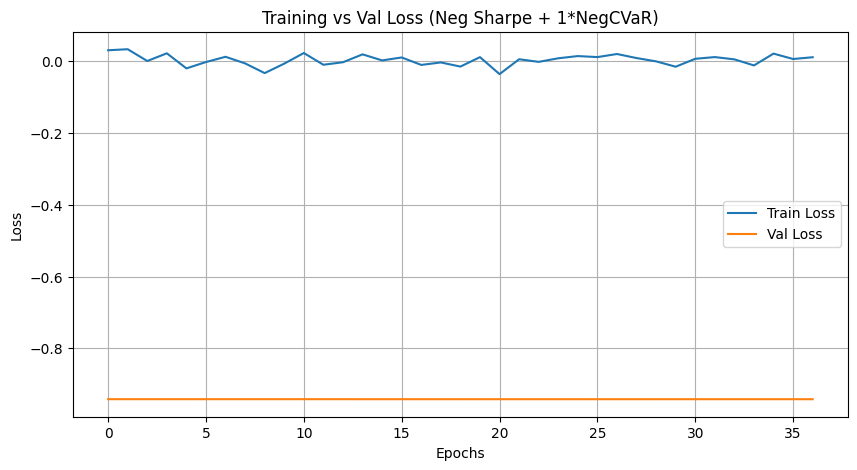

In [15]:
# Visualize Training History
plt.figure(figsize=(10, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title(f"Training vs Val Loss (Neg Sharpe + {CONFIG['lambda_cvar']}*NegCVaR)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# --- Walk-forward retraining evaluation ---

n_graphs = len(all_graphs)

# Approximate graphs per year (one graph per trading day)
graphs_per_year = 252

# Define regime lengths in YEARS
# Example: ~4-year regime: 3y train, 0.5y val, 0.5y test
train_years = 3.0
val_years   = 0.5
test_years  = 0.5

# Convert to number of graphs
train_size = int(train_years * graphs_per_year)  # ~756
val_size   = int(val_years   * graphs_per_year)  # ~126
test_size  = int(test_years  * graphs_per_year)  # ~126

# Slide forward by one test window (non-overlapping test periods)
step_size  = test_size

print(f"Total graphs: {n_graphs}")
print(f"Train size: {train_size}, Val size: {val_size}, Test size: {test_size}, Step size: {step_size}")

splits_wf = generate_walk_forward_splits(
    n_graphs=n_graphs,
    train_size=train_size,
    val_size=val_size,
    test_size=test_size,
    step_size=step_size
)

print(f"Number of walk-forward splits: {len(splits_wf)}")

walk_forward_results = []

for i, (train_idx, val_idx, test_idx) in enumerate(splits_wf, 1):
    print(f"\n=== Walk-forward split {i} ===")
    print(
        f"Train: {train_idx[0]}–{train_idx[-1]}, "
        f"Val: {val_idx[0]}–{val_idx[-1]}, "
        f"Test: {test_idx[0]}–{test_idx[-1]}"
    )

    # Build graph subsets
    train_split = [all_graphs[j] for j in train_idx]
    val_split   = [all_graphs[j] for j in val_idx]
    test_split  = [all_graphs[j] for j in test_idx]

    # Train a fresh model on this split
    model_split, history_split, best_val_loss_split = train_one_model(
        train_split, val_split, CONFIG, device
    )

    # Evaluate on this split's test window
    test_loader_split = DataLoader(test_split, batch_size=CONFIG["batch_size"], shuffle=False)
    test_returns_split = get_portfolio_returns_from_loader(test_loader_split, model_split, device)

    sharpe_daily_split = sharpe_from_returns(test_returns_split)
    sharpe_20d_split   = sharpe_over_blocks(test_returns_split, block_size=20)
    sharpe_ann_split   = sharpe_daily_split * (252 ** 0.5)

    walk_forward_results.append({
        "split": i,
        "train_start": train_idx[0],
        "train_end": train_idx[-1],
        "test_start": test_idx[0],
        "test_end": test_idx[-1],
        "best_val_loss": best_val_loss_split,
        "sharpe_daily": sharpe_daily_split,
        "sharpe_20d": sharpe_20d_split,
        "sharpe_ann": sharpe_ann_split,
    })

# Print aggregate results
print("\nWalk-forward performance (retraining each window):")
for res in walk_forward_results:
    print(
        f"Split {res['split']:02d} "
        f"(train {res['train_start']}–{res['train_end']}, test {res['test_start']}–{res['test_end']}): "
        f"Daily Sharpe={res['sharpe_daily']:.3f}, "
        f"20d Sharpe={res['sharpe_20d']:.3f}, "
        f"Annualized Sharpe={res['sharpe_ann']:.3f}, "
        f"Best Val Loss={res['best_val_loss']:.4f}"
    )


Total graphs: 2197
Train size: 756, Val size: 126, Test size: 126, Step size: 126
Number of walk-forward splits: 10

=== Walk-forward split 1 ===
Train: 0–755, Val: 756–881, Test: 882–1007

=== Walk-forward split 2 ===
Train: 126–881, Val: 882–1007, Test: 1008–1133

=== Walk-forward split 3 ===
Train: 252–1007, Val: 1008–1133, Test: 1134–1259

=== Walk-forward split 4 ===
Train: 378–1133, Val: 1134–1259, Test: 1260–1385

=== Walk-forward split 5 ===
Train: 504–1259, Val: 1260–1385, Test: 1386–1511

=== Walk-forward split 6 ===
Train: 630–1385, Val: 1386–1511, Test: 1512–1637

=== Walk-forward split 7 ===
Train: 756–1511, Val: 1512–1637, Test: 1638–1763

=== Walk-forward split 8 ===
Train: 882–1637, Val: 1638–1763, Test: 1764–1889

=== Walk-forward split 9 ===
Train: 1008–1763, Val: 1764–1889, Test: 1890–2015

=== Walk-forward split 10 ===
Train: 1134–1889, Val: 1890–2015, Test: 2016–2141

Walk-forward performance (retraining each window):
Split 01 (train 0–755, test 882–1007): Daily Sh